In [49]:
# imprts
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis_ad_ab import (
    load_adab_participant,
    summarize_participant_adab,
    collect_calibration_points,
    plot_adab_trial_grid,
    plot_combined_parasitic_relationship,
    add_calibration_variability,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
# participant movement windows
PARTICIPANTS = {
    "11_2_25": {
        "root_dir": "CSV Data/11_2_25",
        "windows_first": [
            (0.00, 3.44, 3.45, 9.84), # Note: video cuts out during movement 
            (0.00, 3.39, 3.40, 9.90),
            (0.00, 3.34, 3.35, 9.90),
        ],
        "windows_second": [
            (0.00, 3.39, 3.40, 9.84),
            (0.00, 3.49, 3.50, 9.90),
            (0.00, 3.34, 3.35, 9.84),
        ],
    },
    "11_4_25": {
        "root_dir": "CSV Data/11_4_25",
        "windows_first": [
            (0.00, 3.44, 3.45, 9.84),
            (0.00, 3.44, 3.45, 9.90),
            (0.00, 3.39, 3.40, 9.84),
        ],
        "windows_second": [
            (0.00, 3.39, 3.40, 9.84), # Note: finger goes past 20 degree mark and seems to be slightly lifting off the table
            (0.00, 3.39, 3.40, 9.90),
            (0.00, 3.39, 3.40, 9.90),
        ],
    },
    "11_7_25": {
        "root_dir": "CSV Data/11_7_25",
        "windows_first": [
            (0.00, 3.59, 3.60, 9.84),
            (0.00, 3.54, 3.55, 9.84),
            (0.00, 3.49, 3.50, 9.90),
        ],
        "windows_second": [
            (0.00, 3.42, 3.43, 9.90),
            (0.00, 3.39, 3.40, 9.90),
            (0.00, 3.59, 3.60, 9.84),
        ],
    },
}

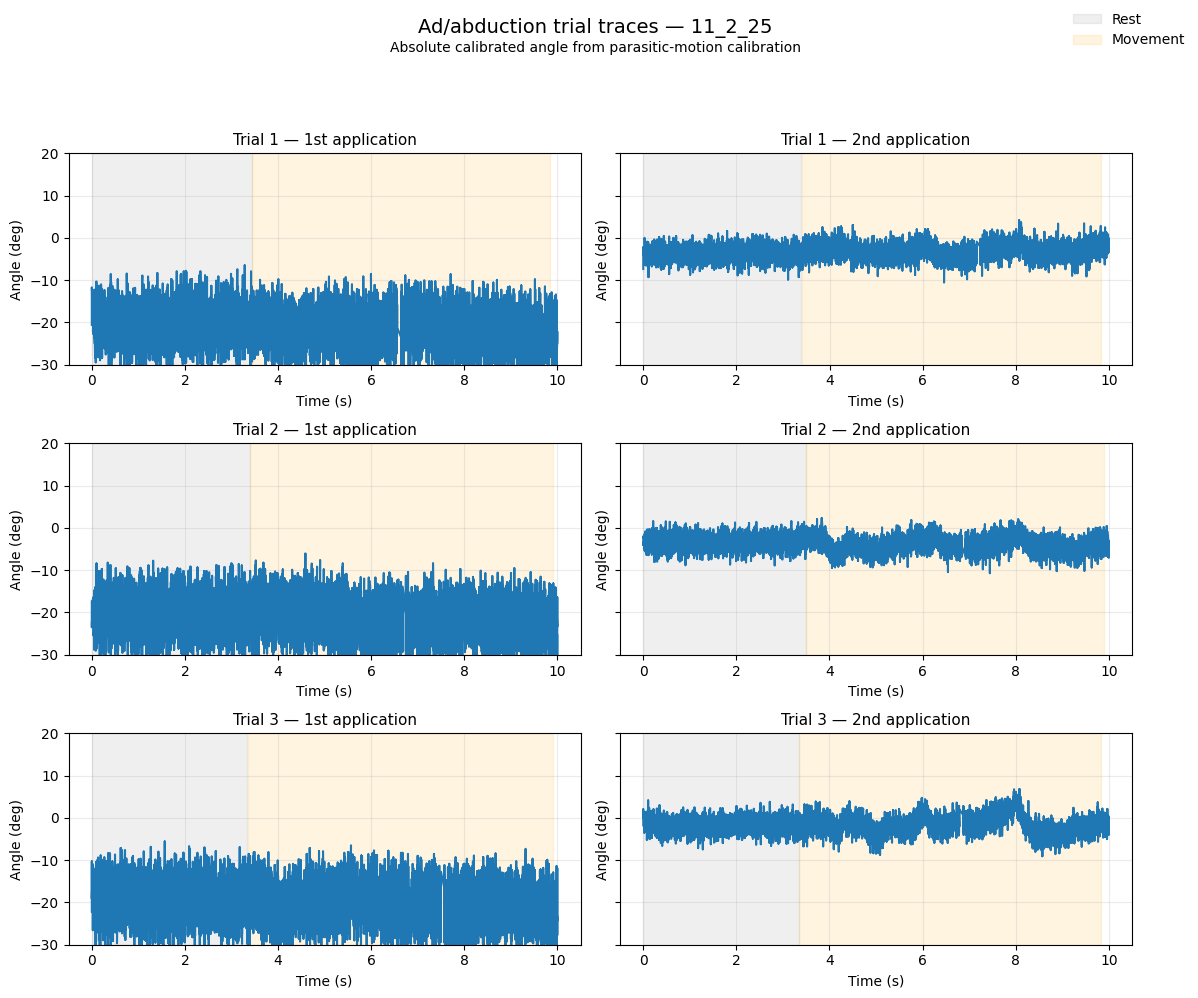

In [51]:
res_11_2 = load_adab_participant(
    participant="11_2_25",
    root_dir=PARTICIPANTS["11_2_25"]["root_dir"],
    clamp_theta=False,  # start unclamped so we can see offsets
)

plot_adab_trial_grid(
    res_11_2,
    windows_first=PARTICIPANTS["11_2_25"]["windows_first"],
    windows_second=PARTICIPANTS["11_2_25"]["windows_second"],
    y_col="theta_cam_cal",
    y_label="Angle (deg)",
    fig_title="Ad/abduction trial traces — 11_2_25",
    fig_subtitle="Absolute calibrated angle from parasitic-motion calibration",
    ylim=(-30,20),
);

# same plots for MCP to compare jump from app1 -> app2 just use first speed -- checking for 10dg offset

In [52]:
summary_11_2 = summarize_participant_adab(
    res_11_2,
    windows_first=PARTICIPANTS["11_2_25"]["windows_first"],
    windows_second=PARTICIPANTS["11_2_25"]["windows_second"],
)

summary_11_2

,participant,application,trial,rest_start_s,rest_end_s,move_start_s,move_end_s,rest_angle_n,rest_angle_mean,rest_angle_std,...,rest_adc_min,rest_adc_max,rest_adc_ptp,move_adc_n,move_adc_mean,move_adc_std,move_adc_min,move_adc_max,move_adc_ptp,move_mean_minus_rest_mean_adc
0,11_2_25,app1,1,0.0,3.44,3.45,9.84,2395,-20.061278,4.537679,...,9123145.0,9170931.0,47786.0,4445,9.149614e+06,8131.899918,9126900.0,9174686.0,47786.0,2345.565626
1,11_2_25,app1,2,0.0,3.39,3.40,9.90,2360,-20.100195,4.773047,...,9125535.0,9173662.0,48127.0,4535,9.149296e+06,8326.020388,9122292.0,9175368.0,53076.0,1971.218694
2,11_2_25,app1,3,0.0,3.34,3.35,9.90,2320,-19.019043,4.869226,...,9121439.0,9169907.0,48468.0,4560,9.147249e+06,8519.360351,9123145.0,9174003.0,50858.0,1787.336993
3,11_2_25,app2,1,0.0,3.39,3.40,9.84,2365,-3.712866,1.670344,...,9145161.0,9173321.0,28160.0,4485,9.156933e+06,4593.430402,9138505.0,9175027.0,36522.0,-1521.558873
4,11_2_25,app2,2,0.0,3.49,3.50,9.90,2430,-3.279098,1.659454,...,9145161.0,9170931.0,25770.0,4440,9.159185e+06,4747.532273,9143454.0,9175368.0,31914.0,1796.154719
5,11_2_25,app2,3,0.0,3.34,3.35,9.84,2325,-1.721735,1.675096,...,9138846.0,9167518.0,28672.0,4515,9.153307e+06,5782.893168,9131849.0,9171443.0,39594.0,-235.531199


In [53]:
summary_clean = summary_11_2[
    [
        "participant",
        "application",
        "trial",
        "movement_mean_angle_deg",
        "movement_peak_angle_deg",
        "movement_ptp_angle_deg",
        "move_mean_minus_rest_mean_angle",
        "rest_adc_mean",
        "move_adc_mean",
        "move_mean_minus_rest_mean_adc",
    ]
].copy()

summary_clean = summary_clean.rename(columns={
    "move_mean_minus_rest_mean_angle": "move_mean_minus_rest_mean_angle_deg"
})

summary_clean

,participant,application,trial,movement_mean_angle_deg,movement_peak_angle_deg,movement_ptp_angle_deg,move_mean_minus_rest_mean_angle_deg,rest_adc_mean,move_adc_mean,move_mean_minus_rest_mean_adc
0,11_2_25,app1,1,-21.441784,-8.515046,28.231370,-1.380506,9.147269e+06,9.149614e+06,2345.565626
1,11_2_25,app1,2,-21.257755,-6.028952,31.152728,-1.157559,9.147325e+06,9.149296e+06,1971.218694
2,11_2_25,app1,3,-20.061832,-6.486025,29.825401,-1.042790,9.145462e+06,9.147249e+06,1787.336993
3,11_2_25,app2,1,-3.095621,4.256263,14.830551,0.617245,9.158454e+06,9.156933e+06,-1521.558873
4,11_2_25,app2,2,-4.013233,2.312202,13.030237,-0.734135,9.157389e+06,9.159185e+06,1796.154719
5,11_2_25,app2,3,-1.633552,6.838443,15.907819,0.088183,9.153543e+06,9.153307e+06,-235.531199


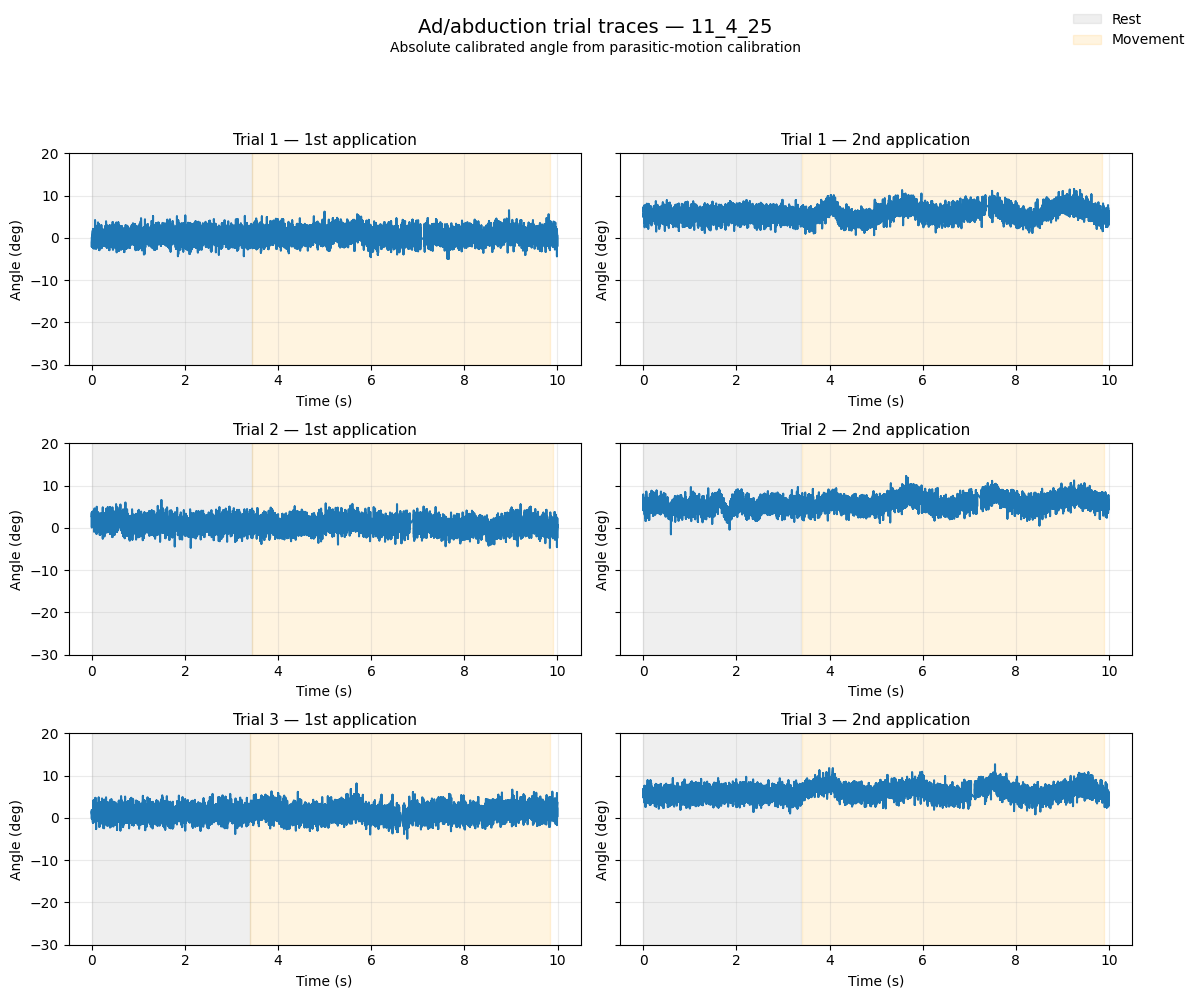

In [54]:
res_11_4 = load_adab_participant(
    participant="11_4_25",
    root_dir=PARTICIPANTS["11_4_25"]["root_dir"],
    clamp_theta=False,
)

plot_adab_trial_grid(
    res_11_4,
    windows_first=PARTICIPANTS["11_4_25"]["windows_first"],
    windows_second=PARTICIPANTS["11_4_25"]["windows_second"],
    y_col="theta_cam_cal",
    y_label="Angle (deg)",
    fig_title="Ad/abduction trial traces — 11_4_25",
    fig_subtitle="Absolute calibrated angle from parasitic-motion calibration",
    ylim=(-30, 20),
);

In [55]:
summary_11_4 = summarize_participant_adab(
    res_11_4,
    windows_first=PARTICIPANTS["11_4_25"]["windows_first"],
    windows_second=PARTICIPANTS["11_4_25"]["windows_second"],
)

summary_11_4

,participant,application,trial,rest_start_s,rest_end_s,move_start_s,move_end_s,rest_angle_n,rest_angle_mean,rest_angle_std,...,rest_adc_min,rest_adc_max,rest_adc_ptp,move_adc_n,move_adc_mean,move_adc_std,move_adc_min,move_adc_max,move_adc_ptp,move_mean_minus_rest_mean_adc
0,11_4_25,app1,1,0.0,3.44,3.45,9.84,2400,0.514547,1.477023,...,9145673.0,9170419.0,24746.0,4450,9.157508e+06,3972.487294,9142430.0,9171955.0,29525.0,-344.080253
1,11_4_25,app1,2,0.0,3.44,3.45,9.90,2395,0.973580,1.519977,...,9142430.0,9171443.0,29013.0,4485,9.157547e+06,3908.985230,9144478.0,9171443.0,26965.0,874.238167
2,11_4_25,app1,3,0.0,3.39,3.40,9.84,2360,1.127807,1.492781,...,9144649.0,9169054.0,24405.0,4480,9.155869e+06,4023.946846,9138505.0,9171955.0,33450.0,-407.425647
3,11_4_25,app2,1,0.0,3.39,3.40,9.84,2365,5.353999,1.282036,...,9148574.0,9172467.0,23893.0,4475,9.157582e+06,5113.468349,9140724.0,9174003.0,33279.0,-2094.318753
4,11_4_25,app2,2,0.0,3.39,3.40,9.90,2360,5.108520,1.426069,...,9146526.0,9180488.0,33962.0,4515,9.157363e+06,4714.386249,9138676.0,9174174.0,35498.0,-3060.671308
5,11_4_25,app2,3,0.0,3.39,3.40,9.90,2365,5.567191,1.303002,...,9146356.0,9172809.0,26453.0,4520,9.156721e+06,4652.271744,9137481.0,9173321.0,35840.0,-2306.128932


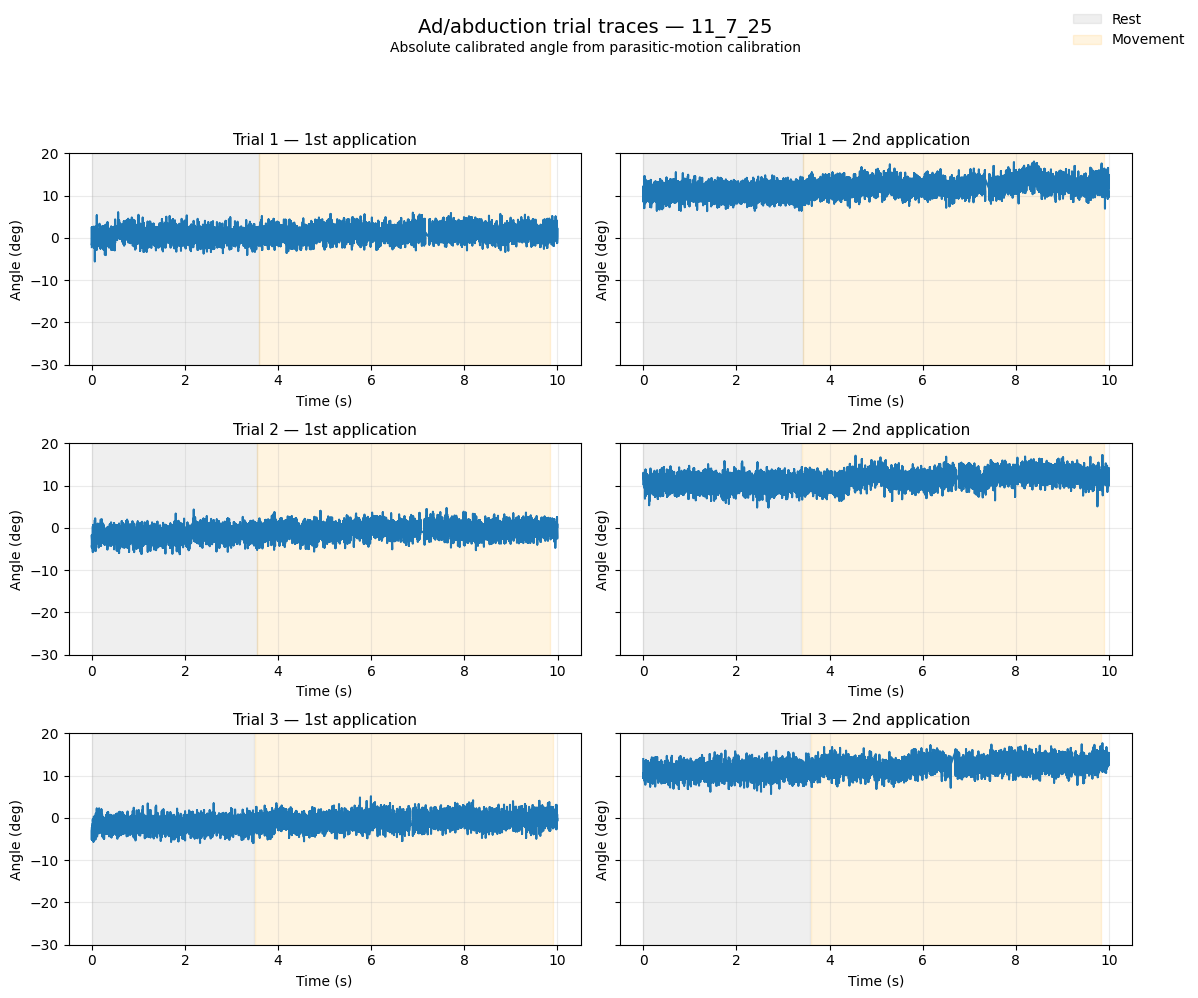

In [56]:
res_11_7 = load_adab_participant(
    participant="11_7_25",
    root_dir=PARTICIPANTS["11_7_25"]["root_dir"],
    clamp_theta=False,
)

plot_adab_trial_grid(
    res_11_7,
    windows_first=PARTICIPANTS["11_7_25"]["windows_first"],
    windows_second=PARTICIPANTS["11_7_25"]["windows_second"],
    y_col="theta_cam_cal",
    y_label="Angle (deg)",
    fig_title="Ad/abduction trial traces — 11_7_25",
    fig_subtitle="Absolute calibrated angle from parasitic-motion calibration",
    ylim=(-30, 20),
);

# look at calibration curve of each app 1v2 to see if that messes w offset
# combine across participants, trials, 


In [57]:
summary_11_7 = summarize_participant_adab(
    res_11_7,
    windows_first=PARTICIPANTS["11_7_25"]["windows_first"],
    windows_second=PARTICIPANTS["11_7_25"]["windows_second"],
)

summary_11_7

,participant,application,trial,rest_start_s,rest_end_s,move_start_s,move_end_s,rest_angle_n,rest_angle_mean,rest_angle_std,...,rest_adc_min,rest_adc_max,rest_adc_ptp,move_adc_n,move_adc_mean,move_adc_std,move_adc_min,move_adc_max,move_adc_ptp,move_mean_minus_rest_mean_adc
0,11_7_25,app1,1,0.0,3.59,3.60,9.84,2500,0.612884,1.461110,...,9105055.0,9134238.0,29183.0,4335,9.117083e+06,3707.707803,9105226.0,9129119.0,23893.0,-1538.108569
1,11_7_25,app1,2,0.0,3.54,3.55,9.84,2465,-1.585435,1.472367,...,9109322.0,9135945.0,26623.0,4370,9.121529e+06,3729.604200,9108298.0,9134409.0,26111.0,-2650.812946
2,11_7_25,app1,3,0.0,3.49,3.50,9.90,2430,-1.660329,1.441975,...,9111540.0,9135262.0,23722.0,4460,9.121617e+06,3854.747509,9107274.0,9134238.0,26964.0,-2752.365843
3,11_7_25,app2,1,0.0,3.42,3.43,9.90,2385,10.819691,1.491233,...,9059658.0,9082015.0,22357.0,4495,9.067395e+06,4043.783606,9053002.0,9080138.0,27136.0,-3831.936037
4,11_7_25,app2,2,0.0,3.39,3.40,9.90,2360,10.528366,1.512658,...,9058805.0,9085429.0,26624.0,4530,9.068663e+06,4104.118002,9055221.0,9084917.0,29696.0,-3272.747695
5,11_7_25,app2,3,0.0,3.59,3.60,9.84,2500,11.118835,1.493311,...,9058634.0,9083381.0,24747.0,4330,9.067403e+06,3862.093999,9054709.0,9080821.0,26112.0,-3094.114691


In [58]:
# all participants
results = {}
summary_tables = []
calib_tables = []

for participant, spec in PARTICIPANTS.items():
    result = load_adab_participant(
        participant=participant,
        root_dir=spec["root_dir"],
        clamp_theta=False,
    )
    results[participant] = result

    summary_df = summarize_participant_adab(
        result,
        windows_first=spec["windows_first"],
        windows_second=spec["windows_second"],
    )
    summary_tables.append(summary_df)

    calib_df = collect_calibration_points(result)
    calib_tables.append(calib_df)

In [59]:
all_summary = pd.concat(summary_tables, ignore_index=True)
all_calib = pd.concat(calib_tables, ignore_index=True)

all_summary

,participant,application,trial,rest_start_s,rest_end_s,move_start_s,move_end_s,rest_angle_n,rest_angle_mean,rest_angle_std,...,rest_adc_min,rest_adc_max,rest_adc_ptp,move_adc_n,move_adc_mean,move_adc_std,move_adc_min,move_adc_max,move_adc_ptp,move_mean_minus_rest_mean_adc
0,11_2_25,app1,1,0.0,3.44,3.45,9.84,2395,-20.061278,4.537679,...,9123145.0,9170931.0,47786.0,4445,9.149614e+06,8131.899918,9126900.0,9174686.0,47786.0,2345.565626
1,11_2_25,app1,2,0.0,3.39,3.40,9.90,2360,-20.100195,4.773047,...,9125535.0,9173662.0,48127.0,4535,9.149296e+06,8326.020388,9122292.0,9175368.0,53076.0,1971.218694
2,11_2_25,app1,3,0.0,3.34,3.35,9.90,2320,-19.019043,4.869226,...,9121439.0,9169907.0,48468.0,4560,9.147249e+06,8519.360351,9123145.0,9174003.0,50858.0,1787.336993
3,11_2_25,app2,1,0.0,3.39,3.40,9.84,2365,-3.712866,1.670344,...,9145161.0,9173321.0,28160.0,4485,9.156933e+06,4593.430402,9138505.0,9175027.0,36522.0,-1521.558873
4,11_2_25,app2,2,0.0,3.49,3.50,9.90,2430,-3.279098,1.659454,...,9145161.0,9170931.0,25770.0,4440,9.159185e+06,4747.532273,9143454.0,9175368.0,31914.0,1796.154719
5,11_2_25,app2,3,0.0,3.34,3.35,9.84,2325,-1.721735,1.675096,...,9138846.0,9167518.0,28672.0,4515,9.153307e+06,5782.893168,9131849.0,9171443.0,39594.0,-235.531199
6,11_4_25,app1,1,0.0,3.44,3.45,9.84,2400,0.514547,1.477023,...,9145673.0,9170419.0,24746.0,4450,9.157508e+06,3972.487294,9142430.0,9171955.0,29525.0,-344.080253
7,11_4_25,app1,2,0.0,3.44,3.45,9.90,2395,0.973580,1.519977,...,9142430.0,9171443.0,29013.0,4485,9.157547e+06,3908.985230,9144478.0,9171443.0,26965.0,874.238167
8,11_4_25,app1,3,0.0,3.39,3.40,9.84,2360,1.127807,1.492781,...,9144649.0,9169054.0,24405.0,4480,9.155869e+06,4023.946846,9138505.0,9171955.0,33450.0,-407.425647
9,11_4_25,app2,1,0.0,3.39,3.40,9.84,2365,5.353999,1.282036,...,9148574.0,9172467.0,23893.0,4475,9.157582e+06,5113.468349,9140724.0,9174003.0,33279.0,-2094.318753


In [60]:
summary_clean = all_summary[
    [
        "participant",
        "application",
        "trial",
        "movement_mean_angle_deg",
        "movement_peak_angle_deg",
        "movement_ptp_angle_deg",
        "move_mean_minus_rest_mean_angle",
        "rest_adc_mean",
        "move_adc_mean",
        "move_mean_minus_rest_mean_adc",
    ]
].copy()

summary_clean = summary_clean.rename(columns={
    "move_mean_minus_rest_mean_angle": "move_mean_minus_rest_mean_angle_deg"
})

summary_clean

,participant,application,trial,movement_mean_angle_deg,movement_peak_angle_deg,movement_ptp_angle_deg,move_mean_minus_rest_mean_angle_deg,rest_adc_mean,move_adc_mean,move_mean_minus_rest_mean_adc
0,11_2_25,app1,1,-21.441784,-8.515046,28.231370,-1.380506,9.147269e+06,9.149614e+06,2345.565626
1,11_2_25,app1,2,-21.257755,-6.028952,31.152728,-1.157559,9.147325e+06,9.149296e+06,1971.218694
2,11_2_25,app1,3,-20.061832,-6.486025,29.825401,-1.042790,9.145462e+06,9.147249e+06,1787.336993
3,11_2_25,app2,1,-3.095621,4.256263,14.830551,0.617245,9.158454e+06,9.156933e+06,-1521.558873
4,11_2_25,app2,2,-4.013233,2.312202,13.030237,-0.734135,9.157389e+06,9.159185e+06,1796.154719
5,11_2_25,app2,3,-1.633552,6.838443,15.907819,0.088183,9.153543e+06,9.153307e+06,-235.531199
6,11_4_25,app1,1,0.648613,6.551708,11.488445,0.134066,9.157852e+06,9.157508e+06,-344.080253
7,11_4_25,app1,2,0.633388,5.744800,10.484957,-0.340193,9.156673e+06,9.157547e+06,874.238167
8,11_4_25,app1,3,1.286770,8.102322,13.039060,0.158963,9.156277e+06,9.155869e+06,-407.425647
9,11_4_25,app2,1,6.040886,11.560091,10.919028,0.686887,9.159677e+06,9.157582e+06,-2094.318753


In [61]:
summary_grouped = (
    summary_clean
    .groupby(["participant", "application"], as_index=False)
    .agg(
        mean_movement_angle_deg=("movement_mean_angle_deg", "mean"),
        mean_peak_angle_deg=("movement_peak_angle_deg", "mean"),
        mean_ptp_angle_deg=("movement_ptp_angle_deg", "mean"),
        mean_delta_angle_deg=("move_mean_minus_rest_mean_angle_deg", "mean"),
        sd_delta_angle_deg=("move_mean_minus_rest_mean_angle_deg", "std"),
        mean_adc_shift=("move_mean_minus_rest_mean_adc", "mean"),
        sd_adc_shift=("move_mean_minus_rest_mean_adc", "std"),
    )
)

summary_grouped

,participant,application,mean_movement_angle_deg,mean_peak_angle_deg,mean_ptp_angle_deg,mean_delta_angle_deg,sd_delta_angle_deg,mean_adc_shift,sd_adc_shift
0,11_2_25,app1,-20.920457,-7.010008,29.736500,-1.193618,0.171722,2034.707104,284.478268
1,11_2_25,app2,-2.914135,4.468969,14.589535,-0.009569,0.680973,13.021549,1672.764096
2,11_4_25,app1,0.856257,6.799610,11.670821,-0.015721,0.281276,40.910756,722.377388
3,11_4_25,app2,6.159198,12.135680,11.438463,0.815961,0.166958,-2487.039664,507.942747
4,11_7_25,app1,0.037159,5.261122,10.156543,0.914785,0.264920,-2313.762453,673.652327
5,11_7_25,app2,12.207342,17.566506,11.227642,1.385045,0.156401,-3399.599474,384.920271
